In [24]:
import numpy as np
import matplotlib.pyplot as plt
from CoolProp.CoolProp import PropsSI
from scipy.optimize import brentq
from fluids.friction import friction_factor
from ht.conv_internal import Nu_laminar_rectangular_Shan_London, turbulent_Dittus_Boelter

C:\Users\chaco\AppData\Local\Temp\ipykernel_2992\3995809615.py:52: RuntimeWarning: The iteration is not making good progress, as measured by the 
 improvement from the last ten iterations.
  u = fsolve(encontrar_u_interno, u0, args=(V_mps,))


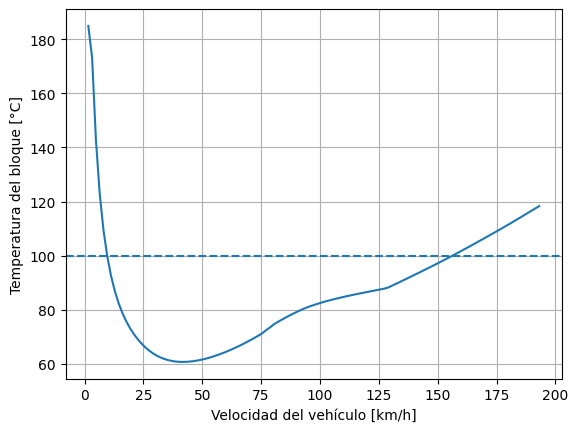


Limites de velocidades
Desde 9.7 km/h hasta 156.1 km/h


In [36]:
V_mph = np.arange(1, 121)
V_mps = V_mph * 0.44704

W_hp = -0.3937 + 0.6300*V_mph + 0.01417*V_mph**2
q_b = W_hp * 745.7   

# Geometría
W = 0.5
H = 0.3
L = 0.1
pf = 0.0012

N = W / pf
D_h = 4 * H * pf / (2 * (H + pf))

A_c = W * H       
A_s = 2 * N * H * L  

T_air = 273.15 + 35
P = 101325

rho_aire = PropsSI('D', 'T', T_air, 'P', P, 'Air')
mu_aire  = PropsSI('V', 'T', T_air, 'P', P, 'Air')
k_aire   = PropsSI('L', 'T', T_air, 'P', P, 'Air')
cp_aire  = PropsSI('C', 'T', T_air, 'P', P, 'Air')
Pr_aire  = cp_aire * mu_aire / k_aire

T_water = 273.15 + 70
cp_agua = PropsSI('C', 'T', T_water, 'P', P, 'Water')

def friction_factor_array(Re):
    Re = np.asarray(Re)

    f_lam = 96 / Re
    f_turb = 0.3164 * Re**(-0.25)

    return np.where(Re < 2300, f_lam, f_turb)


def encontrar_u_interno(u, V_mps):

    Re = rho_aire * u * D_h / mu_aire
    f = friction_factor_array(Re)

    p_dinamica = rho_aire * V_mps**2 / 2

    p_perdida = f * (L / D_h) * (rho_aire * u**2 / 2)

    return p_dinamica - p_perdida

u0 = np.ones_like(V_mps)
u = fsolve(encontrar_u_interno, u0, args=(V_mps,))

Re = rho_aire * u * D_h / mu_aire

def nusselt_rectangular_suave(Re, Pr, H, pf):
    ar = min(H, pf) / max(H, pf)

    Nu_lam = Nu_laminar_rectangular_Shan_London(ar)
    Nu_turb = turbulent_Dittus_Boelter(Re=Re, Pr=Pr, heating=False)

    if Re < 2300:
        return Nu_lam
    elif Re > 4000:
        return Nu_turb
    else:
        w = (Re - 2300) / (4000 - 2300)
        return (1 - w)*Nu_lam + w*Nu_turb

Nu = np.array([nusselt_rectangular_suave(Re_i, Pr_aire, H, pf) for Re_i in Re])

h = Nu * k_aire / D_h
U = h

m_punto_agua = 0.8
C_h = m_punto_agua * cp_agua

m_punto_aire = rho_aire * u * A_c
C_c = m_punto_aire * cp_aire

C_min = np.minimum(C_h, C_c)
C_max = np.maximum(C_h, C_c)
C_r = C_min / C_max

NTU = U * A_s / C_min

epsilon = 1 - np.exp((NTU**0.22 / C_r) * (np.exp(-C_r * NTU**0.78) - 1))

T_inf = 35
Tb = T_inf + q_b / (epsilon * C_min)

# Gráfico
plt.plot(V_mps * 3.6, Tb)
plt.axhline(100, linestyle='--')
plt.xlabel('Velocidad del vehículo [km/h]')
plt.ylabel('Temperatura del bloque [°C]')
plt.grid()
plt.show()

T_lim = 100  # °C

permitido = Tb <= T_lim

# Velocidades discretas que cumplen
V_permitidas = V_mph[permitido]

if len(V_permitidas) == 0:
    print("No hay velocidades permitidas: Tb supera 100 °C en todo el rango.")
else:
    print("\nLimites de velocidades")
    print(f"Desde {V_permitidas[0]*1.60934:.1f} km/h hasta {V_permitidas[-1]*1.60934:.1f} km/h")


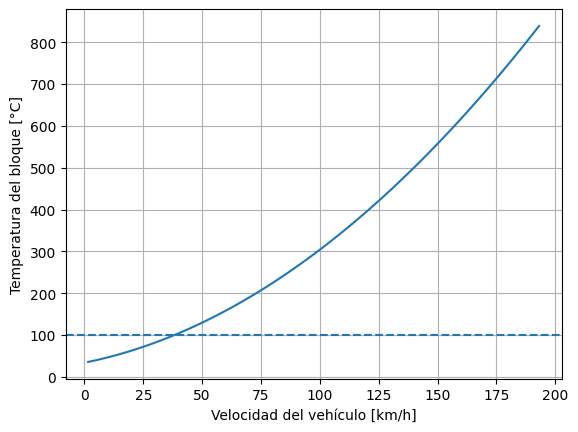


Limites de velocidades
Desde 1.6 km/h hasta 37.0 km/h


In [37]:
V_punto_0 = 500 * 0.000471947
delta_p_agua = 2 * 248.8


def encontrar_u_interno(u, V_mps):

    Re = rho_aire * u * D_h / mu_aire
    f = friction_factor_array(Re)

    p_dinamica = delta_p_agua * (1 - u * A_c/V_punto_0)

    p_perdida = f * (L / D_h) * (rho_aire * u**2 / 2)

    return p_dinamica - p_perdida

u0 = np.ones_like(V_mps)
u = fsolve(encontrar_u_interno, u0, args=(V_mps,))

Re = rho_aire * u * D_h / mu_aire

Nu = np.array([nusselt_rectangular_suave(Re_i, Pr_aire, H, pf) for Re_i in Re])

h = Nu * k_aire / D_h
U = h

m_punto_agua = 0.8
C_h = m_punto_agua * cp_agua

m_punto_aire = rho_aire * u * A_c
C_c = m_punto_aire * cp_aire

C_min = np.minimum(C_h, C_c)
C_max = np.maximum(C_h, C_c)
C_r = C_min / C_max

NTU = U * A_s / C_min

epsilon = 1 - np.exp((NTU**0.22 / C_r) * (np.exp(-C_r * NTU**0.78) - 1))

T_inf = 35
Tb = T_inf + q_b / (epsilon * C_min)

# Gráfico
plt.plot(V_mps * 3.6, Tb)
plt.axhline(100, linestyle='--')
plt.xlabel('Velocidad del vehículo [km/h]')
plt.ylabel('Temperatura del bloque [°C]')
plt.grid()
plt.show()

T_lim = 100  # °C

permitido = Tb <= T_lim

# Velocidades discretas que cumplen
V_permitidas = V_mph[permitido]

if len(V_permitidas) == 0:
    print("No hay velocidades permitidas: Tb supera 100 °C en todo el rango.")
else:
    print("\nLimites de velocidades")
    print(f"Desde {V_permitidas[0]*1.60934:.1f} km/h hasta {V_permitidas[-1]*1.60934:.1f} km/h")